# Handwritten Digit Recognition with CNN (MNIST)

## 1. Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import keras
from keras.datasets import mnist
from keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report

keras.utils.set_random_seed(42)

## 2. Load and preprocess data
Reshape images to (28, 28, 1), scale pixels to [0, 1], and one-hot encode the labels.

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1), (60000, 10), (10000, 10))

## 3. Build the CNN model

In [3]:
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),

    # Block 1: 28x28 -> 14x14
    keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25),

    # Block 2: 14x14 -> 7x7
    keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25),

    # Classifier
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation='softmax'),
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 468,202 (1.79 MB)

 Trainable params: 468,010 (1.79 MB)

 Non-trainable params: 192 (768.00 B)

## 4. Train the model
10% of the training set is held out for validation; the test set is used only for the final evaluation.

In [4]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
]

history = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=20,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/20


844/844 - 25s - 30ms/step - acc: 0.8586 - loss: 0.4357 - val_acc: 0.9818 - val_loss: 0.0648 - learning_rate: 0.0010


Epoch 2/20


844/844 - 23s - 28ms/step - acc: 0.9494 - loss: 0.1592 - val_acc: 0.9890 - val_loss: 0.0443 - learning_rate: 0.0010


Epoch 3/20


...

844/844 - 23s - 27ms/step - acc: 0.9899 - loss: 0.0348 - val_acc: 0.9937 - val_loss: 0.0342 - learning_rate: 5.0000e-04


Epoch 8/20


844/844 - 23s - 27ms/step - acc: 0.9900 - loss: 0.0318 - val_acc: 0.9918 - val_loss: 0.0352 - learning_rate: 5.0000e-04


Epoch 9/20


844/844 - 22s - 26ms/step - acc: 0.9925 - loss: 0.0260 - val_acc: 0.9947 - val_loss: 0.0317 - learning_rate: 2.5000e-04


## 5. Learning curves

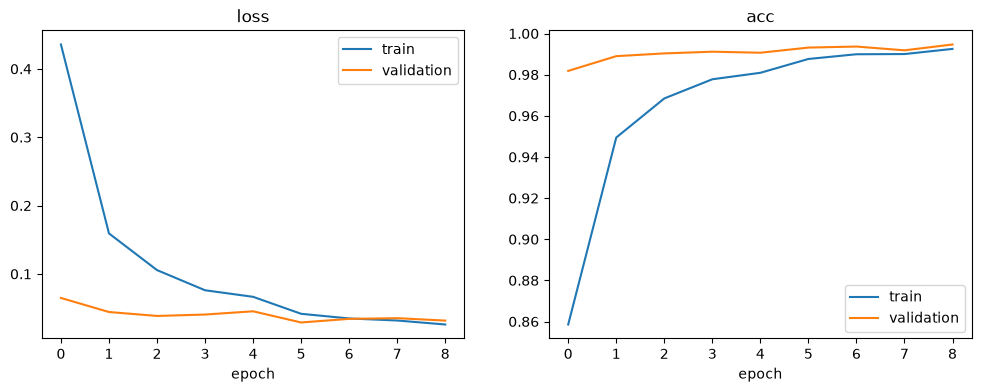

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ['loss', 'acc']):
    ax.plot(history.history[metric], label='train')
    ax.plot(history.history[f'val_{metric}'], label='validation')
    ax.set_title(metric)
    ax.set_xlabel('epoch')
    ax.legend()
plt.show()

## 6. Evaluate on the test set

In [6]:
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test loss     = {loss:.4f}')
print(f'Test accuracy = {acc:.4f}')

y_hat = model.predict(x_test, verbose=0)
true_labels = np.argmax(y_test, axis=1)
predicted_labels = np.argmax(y_hat, axis=1)

print(classification_report(true_labels, predicted_labels, digits=4))

Test loss     = 0.0194
Test accuracy = 0.9943


              precision    recall  f1-score   support

           0     0.9949    0.9990    0.9969       980
           1     0.9947    0.9982    0.9965      1135
           2     0.9971    0.9971    0.9971      1032
           3     0.9921    0.9970    0.9946      1010
           4     0.9980    0.9919    0.9949       982
           5     0.9944    0.9910    0.9927       892
           6     0.9989    0.9916    0.9953       958
           7     0.9875    0.9961    0.9918      1028
           8     0.9938    0.9928    0.9933       974
           9     0.9920    0.9871    0.9896      1009

    accuracy                         0.9943     10000
   macro avg     0.9943    0.9942    0.9943     10000
weighted avg     0.9943    0.9943    0.9943     10000



## 7. Confusion matrix

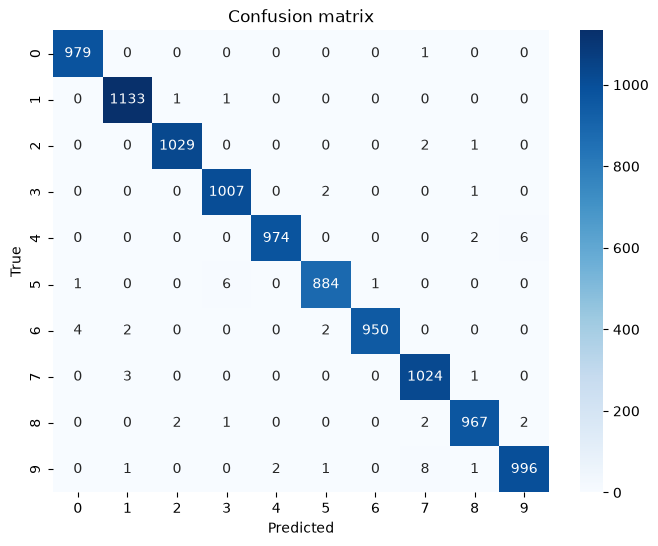

In [7]:
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.show()

## 8. Visualize predictions

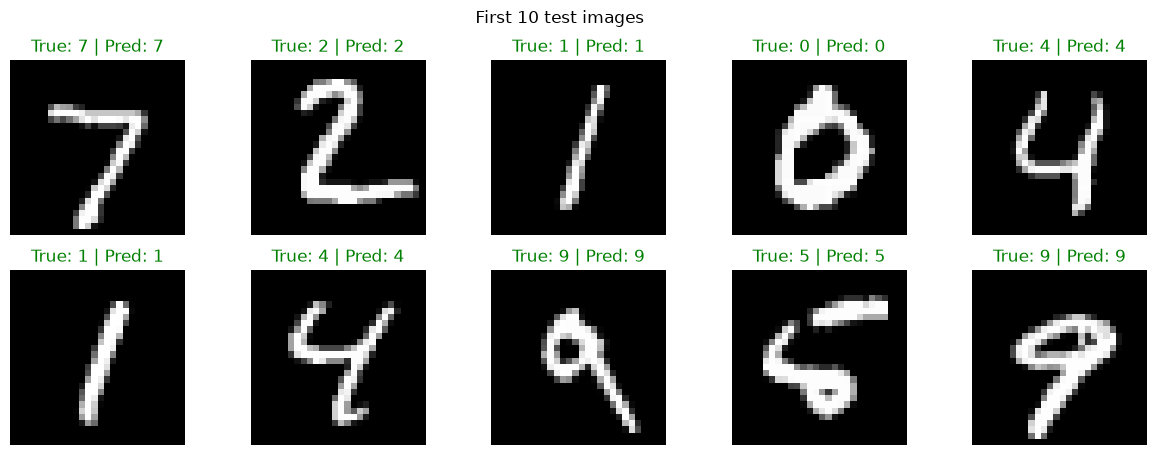

Misclassified images: 57 / 10000


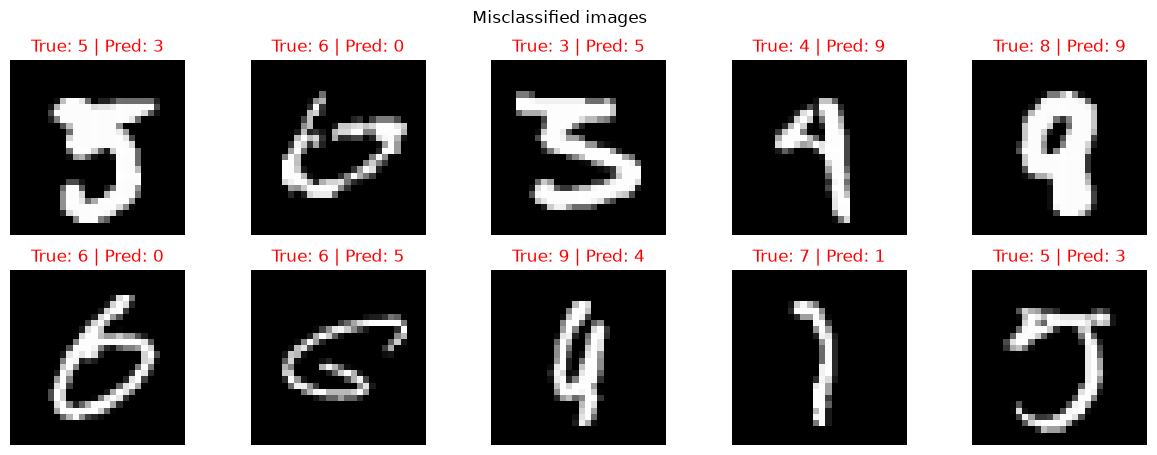

In [8]:
def show_images(indices, title):
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(indices[:10]):
        plt.subplot(2, 5, i + 1)
        plt.imshow(x_test[idx].squeeze(), cmap='gray')
        color = 'green' if true_labels[idx] == predicted_labels[idx] else 'red'
        plt.title(f'True: {true_labels[idx]} | Pred: {predicted_labels[idx]}', color=color)
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

show_images(np.arange(10), 'First 10 test images')

wrong = np.where(true_labels != predicted_labels)[0]
print(f'Misclassified images: {len(wrong)} / {len(x_test)}')
show_images(wrong, 'Misclassified images')

## 9. Save the model

In [9]:
model.save('model.keras')